In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

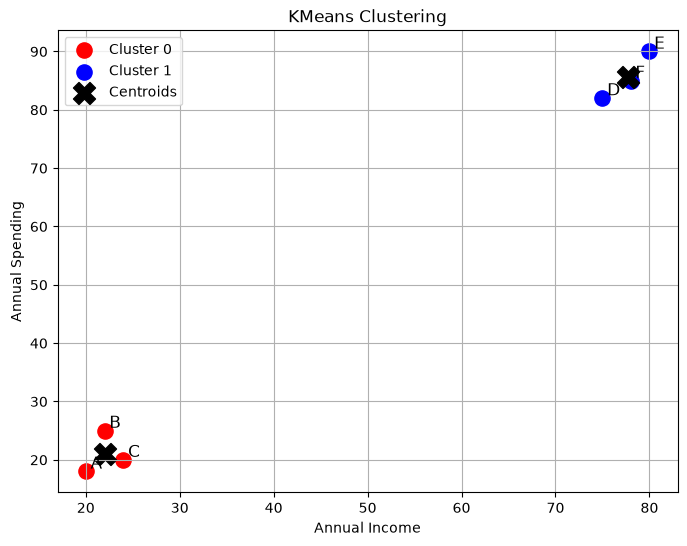

In [17]:


# Create DataFrame
df = pd.DataFrame({
    "Customer": ["A", "B", "C", "D", "E", "F"],
    "Income": [20, 22, 24, 75, 80, 78],
    "Spending": [18, 25, 20, 82, 90, 85]
})

# Select features
X = df[["Income", "Spending"]]

# Apply KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

# Create figure
plt.figure(figsize=(8, 6))

colors = ["red", "blue"]

# Plot clusters
for cluster in range(2):
    cluster_data = df[df["cluster"] == cluster]

    plt.scatter(
        cluster_data["Income"],
        cluster_data["Spending"],
        color=colors[cluster],
        s=120,
        label=f"Cluster {cluster}"
    )

# Plot centroids
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    color="black",
    s=250,
    label="Centroids"
)

# Add customer labels
for i in range(len(df)):
    plt.text(
        df["Income"][i] + 0.5,
        df["Spending"][i] + 0.5,
        df["Customer"][i],
        fontsize=12
    )

# Formatting
plt.title("KMeans Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Annual Spending")
plt.grid(True)
plt.legend()
plt.show()